# Process and inspect Lichess eval games

This notebook is a cleaned-up workspace for feature extraction and plotting.
It uses the package in `../src/chess_eval_features` rather than defining all
functions inline.

Use this notebook for small exploratory runs. For large exports, use
`process_data.py`.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
sys.path.insert(0, str(SRC_DIR))

PROJECT_ROOT


PosixPath('/Users/asudler/Desktop/ucph/coursework/2526-block4/aml/final-project/root/workspace/aidan_sandbox/blunder')

## Imports

The package provides four main stages:

1. stream eval games from the compressed PGN,
2. extract raw per-game and per-ply tables,
3. derive conservative eval/material/phase features,
4. plot game diagnostics.


In [2]:
import pandas as pd

from chess_eval_features.parser import PgnZstParser
from chess_eval_features.extract import build_sequence_tables
from chess_eval_features.features import (
  build_conservative_features,
  merge_features_with_game_metadata,
)
from chess_eval_features.plotting import plot_game_diagnostics
from chess_eval_features.export import process_pgn_to_directory


## Parse a small number of eval games

Keep this small in the notebook. The command-line script is the right tool for
large runs.


In [3]:
pgn_path = PROJECT_ROOT / "data/raw/lichess_db_standard_rated_2017-05.pgn.zst"
n_eval_games = 10

parser = PgnZstParser(pgn_path)
eval_games, scan_report = parser.parse_first_n_with_eval(n_eval_games)

scan_report


{'n_requested_eval_games': 10,
 'n_eval_games_found': 10,
 'n_total_games_scanned': 225}

## Build raw/semi-raw sequence tables

`df_games` has one row per game.

`df_plies` has one row per ply and preserves raw SAN, raw comments, raw evals,
and raw clocks where available.


In [4]:
df_plies, df_games = build_sequence_tables(
  eval_games,
  include_raw_pgn=False,
)

df_games.head()


,game_index,event,site,white,black,result,result_white,white_elo,black_elo,avg_elo,elo_diff_white_minus_black,eco,opening,time_control,termination,time_base_seconds,time_increment_seconds
0,85,Rated Blitz tournament https://lichess.org/tou...,https://lichess.org/ufqUImzs,Lexman661,aspekt,0-1,0.0,1950,1952,1951.0,-2,A01,Nimzo-Larsen Attack: Modern Variation #2,300+0,Normal,300,0
1,90,Rated Blitz tournament https://lichess.org/tou...,https://lichess.org/0xW79X0B,dalila77,ghotir,1/2-1/2,0.5,1738,1733,1735.5,5,B01,Scandinavian Defense: Mieses-Kotroc Variation,300+0,Normal,300,0
2,130,Rated Bullet tournament https://lichess.org/to...,https://lichess.org/avftQQN9,coloviczoki,robrml,1-0,1.0,2136,2001,2068.5,135,B12,"Caro-Kann Defense: Advance Variation, Botvinni...",60+0,Normal,60,0
3,144,Rated Classical game,https://lichess.org/wGdv6qxi,TheYams,amir188,1-0,1.0,1607,1470,1538.5,137,A04,Zukertort Opening: Black Mustang Defense,300+10,Time forfeit,300,10
4,151,Rated Classical tournament https://lichess.org...,https://lichess.org/kbkdiaqQ,arrami01,adondevamos,1-0,1.0,2061,2076,2068.5,-15,B84,"Sicilian Defense: Scheveningen Variation, Clas...",600+0,Time forfeit,600,0


In [5]:
df_plies.head(20)


,game_index,ply,move_number,side,san_raw,comment_raw,eval_raw,eval_pawns,is_mate_eval,mate_distance,clock_raw,clock_seconds
0,85,1,1,white,b3,{ [%eval 0.03] [%clk 0:05:00] },0.03,0.03,False,NaN,0:05:00,300.0
1,85,2,1,black,e5,{ [%eval -0.01] [%clk 0:05:00] },-0.01,-0.01,False,NaN,0:05:00,300.0
2,85,3,2,white,Bb2,{ [%eval -0.09] [%clk 0:04:58] },-0.09,-0.09,False,NaN,0:04:58,298.0
3,85,4,2,black,d6,{ [%eval 0.19] [%clk 0:05:00] },0.19,0.19,False,NaN,0:05:00,300.0
4,85,5,3,white,g3,{ [%eval 0.11] [%clk 0:04:56] },0.11,0.11,False,NaN,0:04:56,296.0
5,85,6,3,black,Nf6,{ [%eval 0.13] [%clk 0:04:58] },0.13,0.13,False,NaN,0:04:58,298.0
6,85,7,4,white,Bg2,{ [%eval -0.13] [%clk 0:04:55] },-0.13,-0.13,False,NaN,0:04:55,295.0
7,85,8,4,black,g6?!,{ [%eval 0.37] [%clk 0:04:57] },0.37,0.37,False,NaN,0:04:57,297.0
8,85,9,5,white,d3,{ [%eval 0.06] [%clk 0:04:36] },0.06,0.06,False,NaN,0:04:36,276.0
9,85,10,5,black,Bg7,{ [%eval 0.05] [%clk 0:04:56] },0.05,0.05,False,NaN,0:04:56,296.0


## Derive features

`df_plies_feat` is the per-ply table enriched with eval proxies, material,
board-state information, and soft phase weights.

`df_features` is one row per game with conservative aggregate features.


In [6]:
df_features, df_plies_feat = build_conservative_features(df_plies)
df_features = merge_features_with_game_metadata(df_features, df_games)

df_features.head()


,game_index,n_plies,n_eval_available,frac_eval_available,n_missing_eval,frac_missing_eval,n_numeric_eval,n_mate_eval,frac_mate_eval,has_mate_eval,...,black_elo,avg_elo,elo_diff_white_minus_black,event,eco,opening,time_control,time_base_seconds,time_increment_seconds,termination
0,85,62,62,1.000000,0,0.000000,62,0,0.000000,False,...,1952,1951.0,-2,Rated Blitz tournament https://lichess.org/tou...,A01,Nimzo-Larsen Attack: Modern Variation #2,300+0,300,0,Normal
1,90,140,140,1.000000,0,0.000000,140,0,0.000000,False,...,1733,1735.5,5,Rated Blitz tournament https://lichess.org/tou...,B01,Scandinavian Defense: Mieses-Kotroc Variation,300+0,300,0,Normal
2,130,71,70,0.985915,1,0.014085,67,3,0.042254,True,...,2001,2068.5,135,Rated Bullet tournament https://lichess.org/to...,B12,"Caro-Kann Defense: Advance Variation, Botvinni...",60+0,60,0,Normal
3,144,13,13,1.000000,0,0.000000,13,0,0.000000,False,...,1470,1538.5,137,Rated Classical game,A04,Zukertort Opening: Black Mustang Defense,300+10,300,10,Time forfeit
4,151,131,131,1.000000,0,0.000000,127,4,0.030534,True,...,2076,2068.5,-15,Rated Classical tournament https://lichess.org...,B84,"Sicilian Defense: Scheveningen Variation, Clas...",600+0,600,0,Time forfeit


In [7]:
df_plies_feat[[
  "game_index",
  "ply",
  "side",
  "san_raw",
  "eval_proxy",
  "white_material",
  "black_material",
  "phase_progress",
  "opening_like_weight",
  "middlegame_like_weight",
  "endgame_like_weight",
  "board_parse_ok",
]].head(40)


,game_index,ply,side,san_raw,eval_proxy,white_material,black_material,phase_progress,opening_like_weight,middlegame_like_weight,endgame_like_weight,board_parse_ok
0,85,1,white,b3,0.03,39,39,0.000000,1.000000,0.000000,0.000000,True
1,85,2,black,e5,-0.01,39,39,0.000000,1.000000,0.000000,0.000000,True
2,85,3,white,Bb2,-0.09,39,39,0.000000,1.000000,0.000000,0.000000,True
3,85,4,black,d6,0.19,39,39,0.000000,1.000000,0.000000,0.000000,True
4,85,5,white,g3,0.11,39,39,0.000000,1.000000,0.000000,0.000000,True
5,85,6,black,Nf6,0.13,39,39,0.000000,1.000000,0.000000,0.000000,True
6,85,7,white,Bg2,-0.13,39,39,0.000000,1.000000,0.000000,0.000000,True
7,85,8,black,g6?!,0.37,39,39,0.000000,1.000000,0.000000,0.000000,True
8,85,9,white,d3,0.06,39,39,0.000000,1.000000,0.000000,0.000000,True
9,85,10,black,Bg7,0.05,39,39,0.000000,1.000000,0.000000,0.000000,True


## Sanity checks

These quick checks make sure the extraction is behaving as expected.


In [8]:
df_plies_feat["board_parse_ok"].value_counts(dropna=False)


board_parse_ok
True    655
Name: count, dtype: int64

In [9]:
eval_density_by_game = (
  df_plies_feat
  .groupby("game_index")
  .agg(
    n_plies=("ply", "count"),
    n_eval=("has_any_eval", "sum"),
    n_mate_eval=("is_mate_eval", "sum"),
  )
  .reset_index()
)

eval_density_by_game["evals_per_ply"] = (
  eval_density_by_game["n_eval"] /
  eval_density_by_game["n_plies"]
)

eval_density_by_game


,game_index,n_plies,n_eval,n_mate_eval,evals_per_ply
0,85,62,62,0,1.000000
1,90,140,140,0,1.000000
2,130,71,70,3,0.985915
3,144,13,13,0,1.000000
4,151,131,131,4,1.000000
5,184,67,67,0,1.000000
6,200,59,58,2,0.983051
7,209,34,34,4,1.000000
8,219,41,41,0,1.000000
9,224,37,37,0,1.000000


## Plot one game

Change `game_pos` to flip through games.


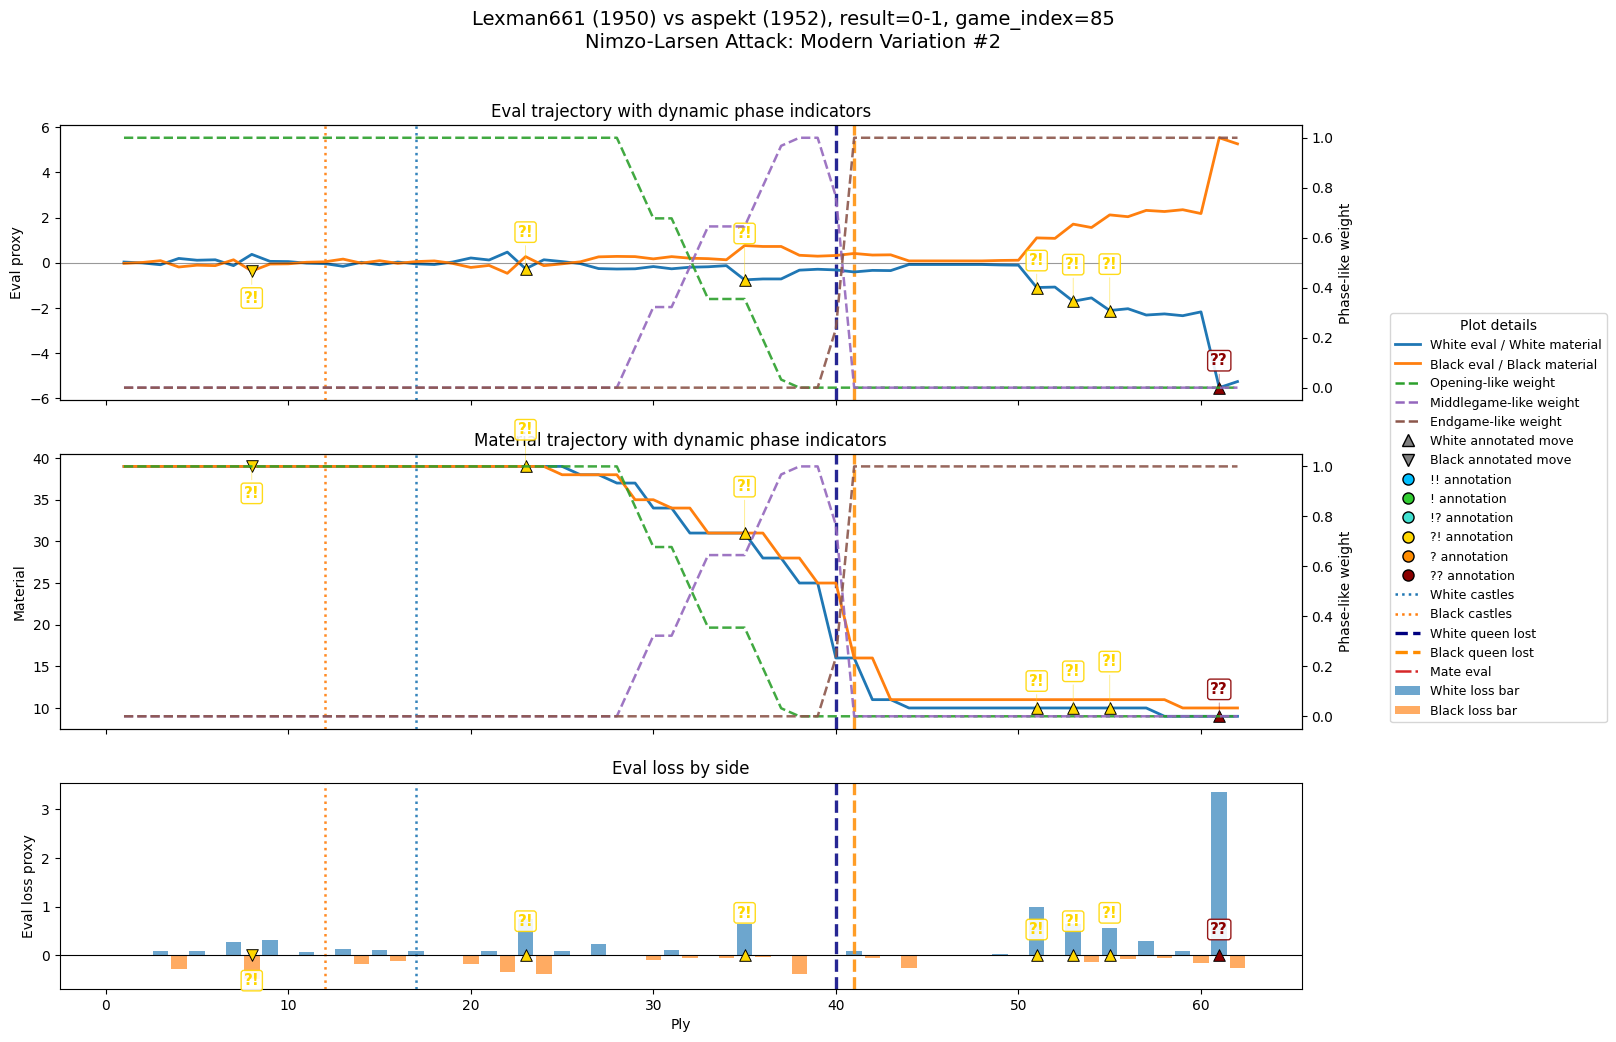

In [10]:
plot_df = plot_game_diagnostics(
  df_plies_feat=df_plies_feat,
  df_games=df_games,
  game_pos=0,
)


In [11]:
plot_df[
  plot_df[[
    "is_annotated_move",
    "is_castle",
    "queen_lost",
    "is_mate_eval",
  ]].any(axis=1)
][[
  "ply",
  "move_number",
  "side",
  "san_raw",
  "move_annotation",
  "eval_proxy",
  "white_material",
  "black_material",
  "is_castle",
  "white_castled",
  "black_castled",
  "white_queen_lost",
  "black_queen_lost",
  "is_mate_eval",
]]


,ply,move_number,side,san_raw,move_annotation,eval_proxy,white_material,black_material,is_castle,white_castled,black_castled,white_queen_lost,black_queen_lost,is_mate_eval
7,8,4,black,g6?!,?!,0.37,39,39,False,False,False,False,False,False
11,12,6,black,O-O,NaN,-0.04,39,39,True,False,True,False,False,False
16,17,9,white,O-O,NaN,-0.05,39,39,True,True,False,False,False,False
22,23,12,white,Re1?!,?!,-0.27,39,39,False,False,False,False,False,False
34,35,18,white,Kg1?!,?!,-0.76,31,31,False,False,False,False,False,False
39,40,20,black,Qxd4,NaN,-0.32,16,25,False,False,False,True,False,False
40,41,21,white,exd4,NaN,-0.41,16,16,False,False,False,False,True,False
50,51,26,white,Rb8?!,?!,-1.10,10,11,False,False,False,False,False,False
52,53,27,white,Rb7?!,?!,-1.71,10,11,False,False,False,False,False,False
54,55,28,white,Rb8?!,?!,-2.12,10,11,False,False,False,False,False,False


## Test dummy export

This writes a small dummy export under `data/processed/_dummy_export`.
Use this to check that the export code works before running a large job.


In [12]:
dummy_output_dir = PROJECT_ROOT / "data/processed/_dummy_export"

manifest = process_pgn_to_directory(
  input_path=pgn_path,
  output_dir=dummy_output_dir,
  n_eval_games=10,
  batch_size=5,
  file_format="csv",
  include_raw_pgn=False,
)

manifest


batch=1 eval_games_written=5 last_game_index=151
batch=2 eval_games_written=10 last_game_index=224


{'created_at_utc': '2026-06-05T18:26:05.035922+00:00',
 'source_file': '/Users/asudler/Desktop/ucph/coursework/2526-block4/aml/final-project/root/workspace/aidan_sandbox/blunder/data/raw/lichess_db_standard_rated_2017-05.pgn.zst',
 'output_dir': '/Users/asudler/Desktop/ucph/coursework/2526-block4/aml/final-project/root/workspace/aidan_sandbox/blunder/data/processed/_dummy_export',
 'n_eval_games_requested': 10,
 'n_eval_games_found': 10,
 'n_total_games_scanned_at_least': 225,
 'batch_size': 5,
 'file_format': 'csv',
 'mate_score': 20.0,
 'clip_value': 20.0,
 'include_raw_pgn': False}

In [13]:
list(dummy_output_dir.iterdir())


[PosixPath('/Users/asudler/Desktop/ucph/coursework/2526-block4/aml/final-project/root/workspace/aidan_sandbox/blunder/data/processed/_dummy_export/plies.csv'),
 PosixPath('/Users/asudler/Desktop/ucph/coursework/2526-block4/aml/final-project/root/workspace/aidan_sandbox/blunder/data/processed/_dummy_export/feature_dictionary.csv'),
 PosixPath('/Users/asudler/Desktop/ucph/coursework/2526-block4/aml/final-project/root/workspace/aidan_sandbox/blunder/data/processed/_dummy_export/games.csv'),
 PosixPath('/Users/asudler/Desktop/ucph/coursework/2526-block4/aml/final-project/root/workspace/aidan_sandbox/blunder/data/processed/_dummy_export/features.csv'),
 PosixPath('/Users/asudler/Desktop/ucph/coursework/2526-block4/aml/final-project/root/workspace/aidan_sandbox/blunder/data/processed/_dummy_export/export_manifest.json')]